# Notebook 1: Train CNN on CIFAR-10

**Goal:** Train a CNN classifier that will be the target for adversarial attacks.

**Output:** Saved model weights in `../results/model.pth`

In [10]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['MKL_WARNINGS'] = '0'

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import sys
sys.path.append('../')

from src.model import CNN

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Using device: cpu


In [2]:
# Load CIFAR-10 dataset
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(root='../data', train=True, download=True, transform=transform_train)
testset  = torchvision.datasets.CIFAR10(root='../data', train=False, download=True, transform=transform_test)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=128, shuffle=False, num_workers=2)

classes = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')
print(f'Train size: {len(trainset)} | Test size: {len(testset)}')

100%|██████████| 170498071/170498071 [04:25<00:00, 641098.27it/s] 


Extracting ../data/cifar-10-python.tar.gz to ../data
Files already downloaded and verified
Train size: 50000 | Test size: 10000


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


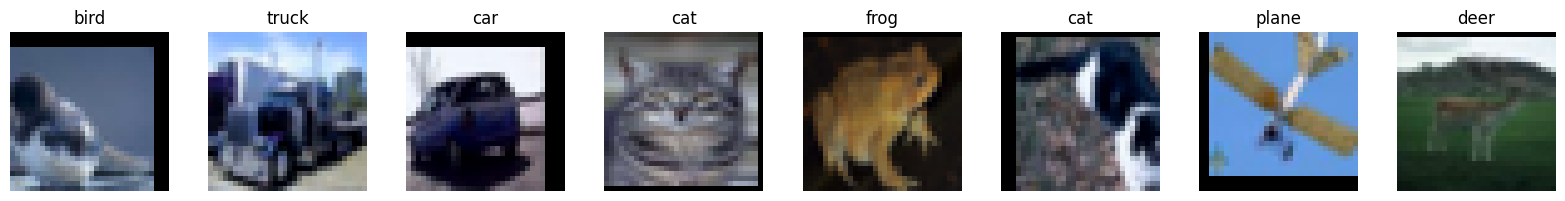

In [3]:
# Visualize some samples
images, labels = next(iter(trainloader))
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    img = images[i].permute(1,2,0).numpy()
    img = img * 0.2 + 0.45  # unnormalize roughly
    ax.imshow(img.clip(0,1))
    ax.set_title(classes[labels[i]])
    ax.axis('off')
plt.tight_layout()
plt.savefig('../results/figures/sample_images.png', dpi=150)
plt.show()

In [4]:
# Initialize model, loss, optimizer
model = CNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')

Model parameters: 667,178


In [5]:
# Training loop
EPOCHS = 30
train_losses, test_accs = [], []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    scheduler.step()

    # Evaluate on test set
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    avg_loss = running_loss / len(trainloader)
    train_losses.append(avg_loss)
    test_accs.append(acc)

    print(f'Epoch [{epoch+1}/{EPOCHS}] Loss: {avg_loss:.4f} | Test Acc: {acc:.4f}')

torch.save(model.state_dict(), '../results/model.pth')
print('Model saved!')

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


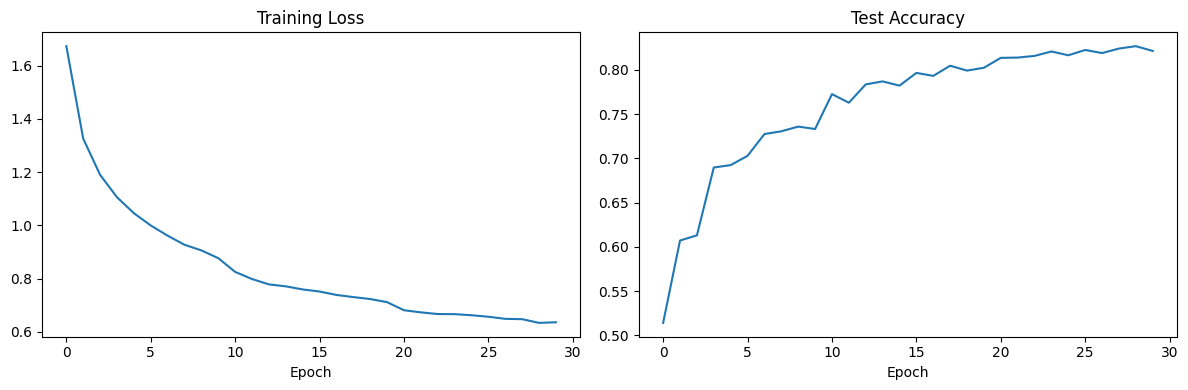

Final test accuracy: 0.8215


In [6]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses)
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax2.plot(test_accs)
ax2.set_title('Test Accuracy')
ax2.set_xlabel('Epoch')
plt.tight_layout()
plt.savefig('../results/figures/training_curves.png', dpi=150)
plt.show()
print(f'Final test accuracy: {test_accs[-1]:.4f}')

In [12]:
class_correct = [0] * 10
class_total   = [0] * 10

model.eval()
with torch.no_grad():
    for imgs, lbls in testloader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        preds = model(imgs).argmax(dim=1)
        for p, t in zip(preds, lbls):
            class_total[t] += 1
            if p == t:
                class_correct[t] += 1

for i in range(10):
    acc = class_correct[i] / class_total[i]
    bar = "█" * int(acc * 20)
    print(f"{classes[i]:8s}: {acc:.1%} {bar}")

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


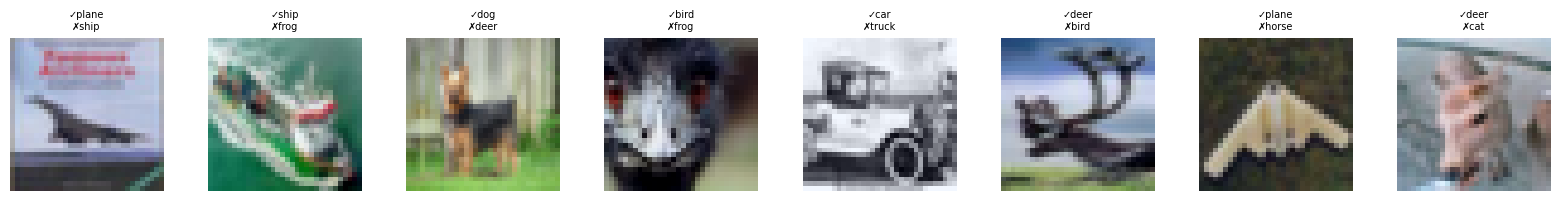

In [13]:
wrong_imgs, wrong_preds, wrong_true = [], [], []

model.eval()
with torch.no_grad():
    for imgs, lbls in testloader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        preds = model(imgs).argmax(dim=1)
        mask = preds != lbls
        for img, p, t in zip(imgs[mask], preds[mask], lbls[mask]):
            wrong_imgs.append(img.cpu())
            wrong_preds.append(p.item())
            wrong_true.append(t.item())
        if len(wrong_imgs) >= 8:
            break

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    img = wrong_imgs[i].permute(1,2,0).numpy()
    img = (img * 0.2 + 0.45).clip(0, 1)
    ax.imshow(img)
    true_label = classes[wrong_true[i]]
    pred_label = classes[wrong_preds[i]]
    ax.set_title(f"✓{true_label}\n✗{pred_label}", fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [11]:
print(testloader.dataset)
print("shuffle:", testloader.sampler)

Dataset CIFAR10
    Number of datapoints: 10000
    Root location: ../data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.2023, 0.1994, 0.201))
           )
shuffle: <torch.utils.data.sampler.SequentialSampler object at 0x1387c3a90>


In [14]:
model.eval()
images, labels = next(iter(testloader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images[:5])
    probs = torch.softmax(outputs, dim=1)

for i in range(5):
    pred = probs[i].argmax().item()
    true = labels[i].item()
    conf = probs[i].max().item()
    print(f"Правильно: {classes[true]:8s} | Предсказано:\
{classes[pred]:8s} | Уверенность: {conf:.1%}")

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [15]:
x = images[:1]
print("Вход:        ", x.shape)

for i, layer in enumerate(model.features):
    x = layer(x)
    print(f"После слоя {i} ({layer.__class__.__name__}): {x.shape}")

Вход:         torch.Size([1, 3, 32, 32])
После слоя 0 (Conv2d): torch.Size([1, 32, 32, 32])
После слоя 1 (BatchNorm2d): torch.Size([1, 32, 32, 32])
После слоя 2 (ReLU): torch.Size([1, 32, 32, 32])
После слоя 3 (Conv2d): torch.Size([1, 32, 32, 32])
После слоя 4 (BatchNorm2d): torch.Size([1, 32, 32, 32])
После слоя 5 (ReLU): torch.Size([1, 32, 32, 32])
После слоя 6 (MaxPool2d): torch.Size([1, 32, 16, 16])
После слоя 7 (Dropout): torch.Size([1, 32, 16, 16])
После слоя 8 (Conv2d): torch.Size([1, 64, 16, 16])
После слоя 9 (BatchNorm2d): torch.Size([1, 64, 16, 16])
После слоя 10 (ReLU): torch.Size([1, 64, 16, 16])
После слоя 11 (Conv2d): torch.Size([1, 64, 16, 16])
После слоя 12 (BatchNorm2d): torch.Size([1, 64, 16, 16])
После слоя 13 (ReLU): torch.Size([1, 64, 16, 16])
После слоя 14 (MaxPool2d): torch.Size([1, 64, 8, 8])
После слоя 15 (Dropout): torch.Size([1, 64, 8, 8])
После слоя 16 (Conv2d): torch.Size([1, 128, 8, 8])
После слоя 17 (BatchNorm2d): torch.Size([1, 128, 8, 8])
После слоя 18 

[W NNPACK.cpp:64] Could not initialize NNPACK! Reason: Unsupported hardware.
